In [202]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.stattools import adfuller
from tqdm import tqdm_notebook
from itertools import product
from typing import Union
import matplotlib.pyplot as plt
import statsmodels.api as sm
from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [20, 10]
%matplotlib inline


In [203]:
# Read data
df_arr = []
for i in range(1, 7):
    df_arr.append(pd.read_csv('../datasets/TX-Data/met-cleanedup/met_data' + str(i) + '_cleaned.csv', sep=",", parse_dates=["Date"], index_col="Date"))
df_arr

[                     Ppt    Tair     RH  Windspeed  Winddirection  Srad
 Date                                                                   
 2014-10-01 00:00:00  0.0  22.130  80.70      1.429          203.2   0.0
 2014-10-01 01:00:00  0.0  21.680  84.70      1.555          201.2   0.0
 2014-10-01 02:00:00  0.0  22.210  89.20      2.288          193.1   0.0
 2014-10-01 03:00:00  0.0  22.410  90.00      2.421          195.4   0.0
 2014-10-01 04:00:00  0.0  22.300  92.60      1.738          191.3   0.0
 ...                  ...     ...    ...        ...            ...   ...
 2021-08-31 20:00:00  0.0  29.100  60.19      1.029          197.1   0.0
 2021-08-31 21:00:00  0.0  29.595  62.28      0.510          199.6   0.0
 2021-08-31 22:00:00  0.0  27.730  63.98        NaN          192.6   0.0
 2021-08-31 23:00:00  0.0  27.300  67.31        NaN          190.2   0.0
 2021-09-01 00:00:00  0.0  26.210  74.82        NaN          197.9   0.0
 
 [60649 rows x 6 columns],
                      

In [204]:
# removes spaces in the column names
def remove_spaces(df):
    df.columns = df.columns.str.replace(' ','')
    df['Ppt'] = df['Ppt'].astype(float)
    df['Tair'] = df['Tair'].astype(float)
    df['RH'] = df['RH'].astype(float)
    df['Windspeed'] = df['Windspeed'].astype(float)
    df['Winddirection'] = df['Winddirection'].astype(float)
    df['Srad'] = df['Srad'].astype(float)  

In [205]:
for (i, df) in enumerate(df_arr):
    print(df)
    remove_spaces(df)
df_arr

                     Ppt    Tair     RH  Windspeed  Winddirection  Srad
Date                                                                   
2014-10-01 00:00:00  0.0  22.130  80.70      1.429          203.2   0.0
2014-10-01 01:00:00  0.0  21.680  84.70      1.555          201.2   0.0
2014-10-01 02:00:00  0.0  22.210  89.20      2.288          193.1   0.0
2014-10-01 03:00:00  0.0  22.410  90.00      2.421          195.4   0.0
2014-10-01 04:00:00  0.0  22.300  92.60      1.738          191.3   0.0
...                  ...     ...    ...        ...            ...   ...
2021-08-31 20:00:00  0.0  29.100  60.19      1.029          197.1   0.0
2021-08-31 21:00:00  0.0  29.595  62.28      0.510          199.6   0.0
2021-08-31 22:00:00  0.0  27.730  63.98        NaN          192.6   0.0
2021-08-31 23:00:00  0.0  27.300  67.31        NaN          190.2   0.0
2021-09-01 00:00:00  0.0  26.210  74.82        NaN          197.9   0.0

[60649 rows x 6 columns]
                     Ppt  Tair  RH  Wi

[                     Ppt    Tair     RH  Windspeed  Winddirection  Srad
 Date                                                                   
 2014-10-01 00:00:00  0.0  22.130  80.70      1.429          203.2   0.0
 2014-10-01 01:00:00  0.0  21.680  84.70      1.555          201.2   0.0
 2014-10-01 02:00:00  0.0  22.210  89.20      2.288          193.1   0.0
 2014-10-01 03:00:00  0.0  22.410  90.00      2.421          195.4   0.0
 2014-10-01 04:00:00  0.0  22.300  92.60      1.738          191.3   0.0
 ...                  ...     ...    ...        ...            ...   ...
 2021-08-31 20:00:00  0.0  29.100  60.19      1.029          197.1   0.0
 2021-08-31 21:00:00  0.0  29.595  62.28      0.510          199.6   0.0
 2021-08-31 22:00:00  0.0  27.730  63.98        NaN          192.6   0.0
 2021-08-31 23:00:00  0.0  27.300  67.31        NaN          190.2   0.0
 2021-09-01 00:00:00  0.0  26.210  74.82        NaN          197.9   0.0
 
 [60649 rows x 6 columns],
                      

In [207]:
# creating mega array and purging data before 2015
mega_arr = pd.concat(df_arr)

# Exclude data with dates before 2015
mega_arr = mega_arr[(mega_arr.index > "2014-12-31 23:00")]

print(mega_arr)

# Fill nan values
mega_arr.replace([np.inf, -np.inf], np.nan, inplace=True)
mega_arr.fillna(reindex_df_Tair.mean(), inplace=True)

mega_arr

                     Ppt   Tair       RH  Windspeed  Winddirection  Srad
Date                                                                    
2014-10-01 00:00:00  0.0  22.13   80.700      1.429          203.2  0.00
2014-10-01 01:00:00  0.0  21.68   84.700      1.555          201.2  0.00
2014-10-01 02:00:00  0.0  22.21   89.200      2.288          193.1  0.00
2014-10-01 03:00:00  0.0  22.41   90.000      2.421          195.4  0.00
2014-10-01 04:00:00  0.0  22.30   92.600      1.738          191.3  0.00
...                  ...    ...      ...        ...            ...   ...
2021-08-31 20:00:00  0.0  31.41  100.000      0.122          181.6  0.02
2021-08-31 21:00:00  0.0  30.31  100.000      0.013          184.3  0.00
2021-08-31 22:00:00  0.0  29.99   67.415      0.309          168.6  0.00
2021-08-31 23:00:00  0.0  29.45  100.000      1.252          172.7  0.00
2021-09-01 00:00:00  0.0  28.70   83.200        NaN          180.2  0.00

[363894 rows x 6 columns]


,Ppt,Tair,RH,Windspeed,Winddirection,Srad
Date,,,,,,
2014-10-01 00:00:00,0.0,22.13,80.700,1.429,203.2,0.00
2014-10-01 01:00:00,0.0,21.68,84.700,1.555,201.2,0.00
2014-10-01 02:00:00,0.0,22.21,89.200,2.288,193.1,0.00
2014-10-01 03:00:00,0.0,22.41,90.000,2.421,195.4,0.00
2014-10-01 04:00:00,0.0,22.30,92.600,1.738,191.3,0.00
...,...,...,...,...,...,...
2021-08-31 20:00:00,0.0,31.41,100.000,0.122,181.6,0.02
2021-08-31 21:00:00,0.0,30.31,100.000,0.013,184.3,0.00
2021-08-31 22:00:00,0.0,29.99,67.415,0.309,168.6,0.00


In [187]:
# create new df for each feature aggregating station data
ppt_df = mega_arr['Ppt']
tair_df = mega_arr['Tair']
rh_df = mega_arr['RH']
ws_df = mega_arr['Windspeed']
wd_df = mega_arr['Winddirection']
sr_df = mega_arr['Srad']

feature_dfs = {
     'Ppt': ppt_df,
     'Tair': tair_df,
     'RH': rh_df,
     'Windspeed': ws_df,
     'Winddirection': wd_df,
     'Srad': sr_df
}

feature_dfs['RH']

Date
2015-01-01 00:00:00     81.500
2015-01-01 01:00:00     81.700
2015-01-01 02:00:00     82.000
2015-01-01 03:00:00     81.900
2015-01-01 04:00:00     90.000
                        ...   
2021-08-31 20:00:00    100.000
2021-08-31 21:00:00    100.000
2021-08-31 22:00:00     67.415
2021-08-31 23:00:00    100.000
2021-09-01 00:00:00     83.200
Name: RH, Length: 350646, dtype: float64

In [192]:
sample_feature_dfs = feature_dfs
for feat in sample_feature_dfs.keys():
    sample_feature_dfs[feat] = sample_feature_dfs[feat].loc["2015"].resample('D').mean()
sample_feature_dfs['RH']

Date
2015-01-01    96.276667
2015-01-02    97.543333
2015-01-03    72.041250
2015-01-04    65.700208
2015-01-05    63.407431
                ...    
2015-12-27    93.465500
2015-12-28    80.562083
2015-12-29    82.083167
2015-12-30    87.990417
2015-12-31    83.286750
Freq: D, Name: RH, Length: 365, dtype: float64

Text(0, 0.5, 'Tair Data in Celsius')

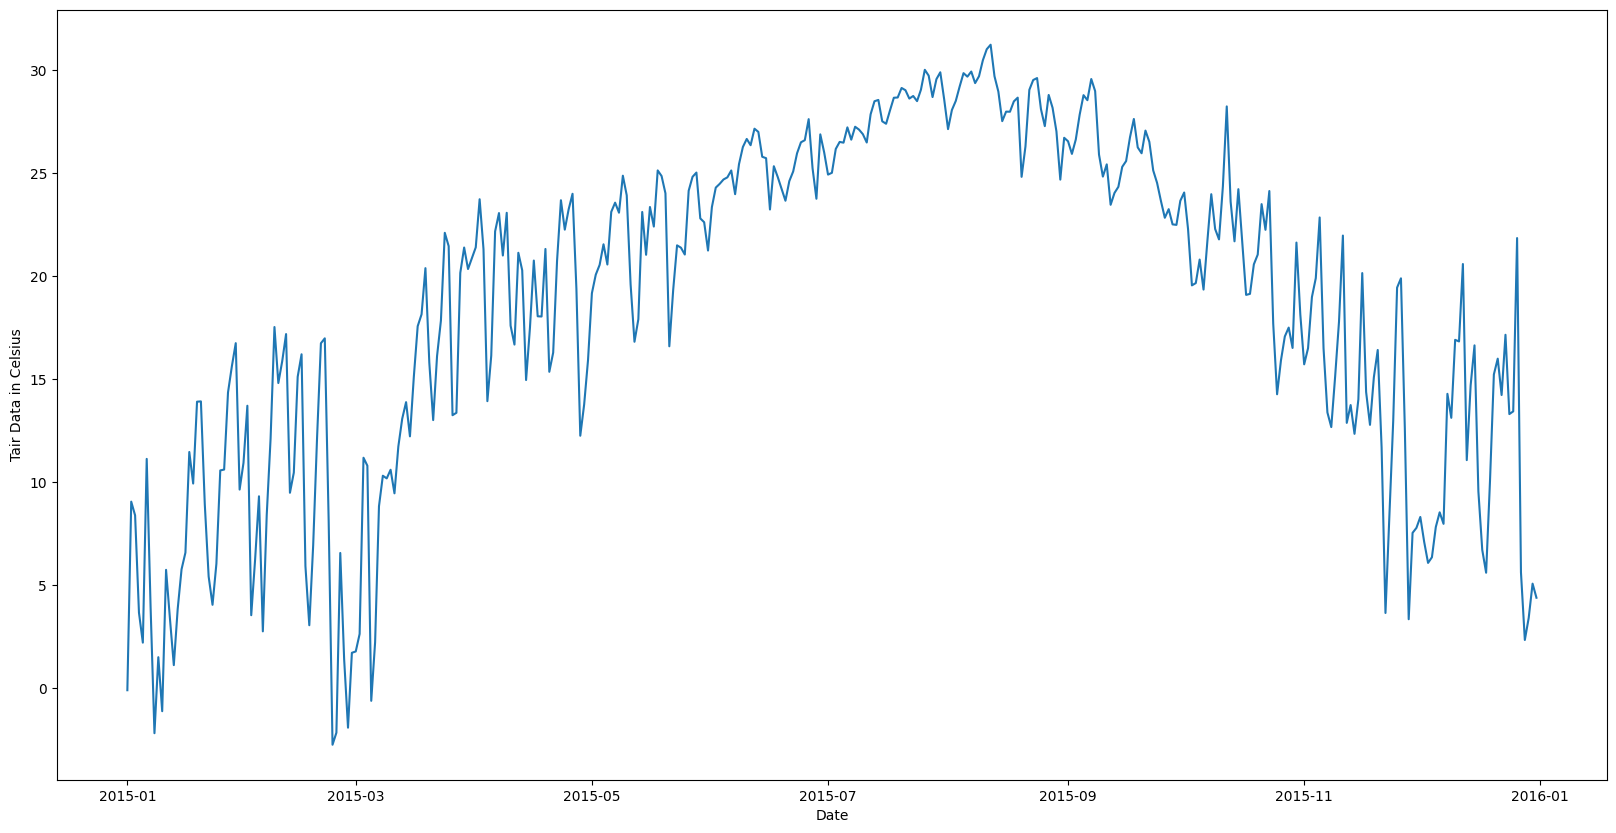

In [170]:
fig, ax = plt.subplots()

ax.plot(update_df_Tair)
ax.set_xlabel('Date')
ax.set_ylabel('Tair Data in Celsius')

    

In [133]:
# stationarity test for stations
sample_feature_dfs = feature_dfs
for feat in sample_feature_dfs.keys():
    sample_feature_dfs[feat]
    ad_fuller_result = adfuller(update_df_Tair)

    print(f'ADF Statistic: {ad_fuller_result[0]}')
    print(f'p-value: {ad_fuller_result[1]}\n')

ADF Statistic: -1.8510112031885544
p-value: 0.3554459621686772



In [214]:
# Train/Test Split

# getting train and test data from our sampled, shorter dataframes
sample_feature_dfs
train = {}
test = {}
for feat in sample_feature_dfs.keys():
    train[feat] = sample_feature_dfs[feat][:'2015-11-17 23:00']
    test[feat] = sample_feature_dfs[feat]['2015-11-17 23:00':]

len(train['Tair'])
len(test['Tair'])


321

In [135]:
# Defining optimize_SARIMAX function
from typing import Union
from tqdm import tqdm_notebook
from statsmodels.tsa.statespace.sarimax import SARIMAX

def optimize_SARIMAX(endog: Union[pd.Series, list], exog: Union[pd.Series, list], order_list: list, d: int, D: int, s: int)->pd.DataFrame:

    results=[]
    
    for order in tqdm_notebook(order_list):
        try:
            model = SARIMAX(
            endog,
            exog,
            order=(order[0], d, order[1]),
            seasonal_order=(order[2], D, order[3], s),
            simple_differencing=False).fit(disp=False)
        except:
            continue
        
        results.append([order, model.aic])
    
    result_df=pd.DataFrame(results)
    result_df.columns = ['(p, q, P, Q)', 'AIC']
    
    # Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    return result_df

In [136]:
# Define range of values for p, q, P, and Q

ps= range(0, 2, 1)
qs= range(0, 2, 1)
Ps= range(0, 2, 1)
Qs= range(0, 2, 1)

# Create list of all unique combinations
order_list = list(product(ps, qs, Ps, Qs))

# Set constants
d=0
D=0
s=12

In [200]:


# Find the (p, d, q) (P, D, Q)m comination with the lowest AIC
SARIMA_result = {}
for feat in sample_feature_dfs.keys():
    SARIMA_result[feat] = (optimize_SARIMAX(train[feat], None, order_list, d, D, s))
SARIMA_result['Tair']

  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

,"(p, q, P, Q)",AIC
0,"(1, 0, 0, 0)",1609.459809
1,"(1, 0, 1, 0)",1610.346613
2,"(1, 0, 1, 1)",1610.358483
3,"(1, 0, 0, 1)",1610.511678
4,"(1, 1, 0, 0)",1611.424049
5,"(1, 1, 1, 1)",1612.300736
6,"(1, 1, 1, 0)",1612.345777
7,"(1, 1, 0, 1)",1612.509352
8,"(0, 1, 1, 1)",1723.813015
9,"(0, 1, 1, 0)",1756.831438


In [201]:
optimal_parameters=[]
result_array=SARIMA_result['Tair']['(p, q, P, Q)']
result_array[0]

(1, 0, 0, 0)

In [139]:
# Fit optimal model to study its residuals

SARIMA_model = SARIMAX(train, order=(result_array[0][0], 0, result_array[0][1]), seasonal_order = (result_array[0][2], 0, result_array[0][3], 12), enforce_invertibility=False)
SARIMA_model_fit = SARIMA_model.fit(disp=False)
print(SARIMA_model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                   Tair   No. Observations:                  321
Model:               SARIMAX(1, 0, 0)   Log Likelihood                -808.696
Date:                Thu, 08 Jun 2023   AIC                           1621.392
Time:                        19:42:32   BIC                           1628.935
Sample:                    01-01-2015   HQIC                          1624.403
                         - 11-17-2015                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9883      0.011     92.175      0.000       0.967       1.009
sigma2         8.9263      0.527     16.942      0.000       7.894       9.959
Ljung-Box (L1) (Q):                   0.00   Jarque-

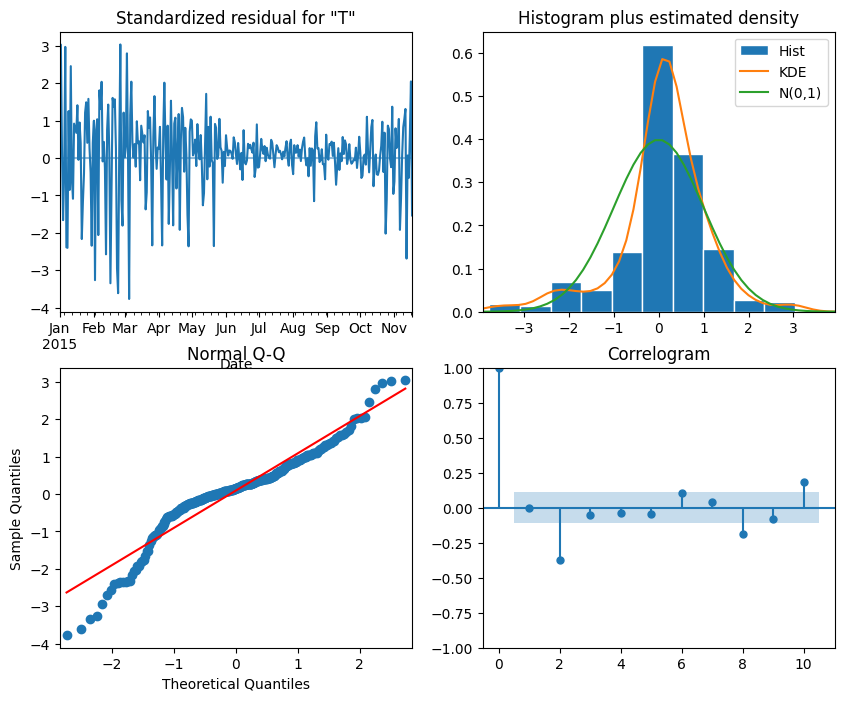

In [140]:
# Plot residual's diagnostics
SARIMA_model_fit.plot_diagnostics(figsize=(10,8));

In [141]:
# Run the Ljung-Box test
residuals = SARIMA_model_fit.resid
lbvalue, pvalue = acorr_ljungbox(residuals, np.arange(1, 3, 1))
print(pvalue)


lb_pvalue


In [150]:
# Function to preform rolling forcasts
def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str) -> list:

    total_len = train_len + horizon
    end_idx = train_len
    
    if method == 'last_season':
        pred_last_season=[]
        
        for i in range(train_len, total_len, window):
            last_season = update_df_Tair['Tair'][i-window:i].values
            pred_last_season.extend(last_season)
            
        return pred_last_season
    
    elif method == 'SARIMA':
        pred_SARIMA = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(update_df_Tair['Tair'][:i], order=(result_array[0][0], 0, result_array[0][1]), seasonal_order = (result_array[0][2], 0, result_array[0][3], 12), simple_differencing=True)
            res = model.fit(disp=False)
            predictions = res.get_predictions(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_SARIMA.extend(oos_pred)
        
        return pred_SARIMA

In [151]:
update_df_Tair
pred_df =update_df_Tair['Tair'][:'2015-12-31 23:00']
print(pred_df)

Date
2015-01-01   -0.201042
2015-01-02    8.857291
2015-01-03    9.448033
2015-01-04    4.379354
2015-01-05    3.178067
                ...   
2015-12-27    5.568125
2015-12-28    2.325341
2015-12-29    3.659146
2015-12-30    5.740017
2015-12-31    4.866875
Freq: D, Name: Tair, Length: 365, dtype: float64


In [152]:
# Define length of training set, horizon of forecast, and the window of forecast
TRAIN_LEN = 9
HORIZON = 3
WINDOW = 1

# Preform rolling forecast with the naive seasonal baseline
pred_df_array = rolling_forecast(update_df_Tair['Tair'], TRAIN_LEN, HORIZON, WINDOW, 'last_season')

#Display the predictions
print(pred_df_array)

[1.3006666666666666, -1.2622916666666666, 6.089916666666666]
